In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utils_plot
import kind

# Evaluating operators trained on measured data

In [2]:
# --!--------------------------------------------------------------------------
# --! load trained models

model = torch.load('models/kind_meas.pt', weights_only=False)
model.eval()

model(
  (operator_sta): operator_stationary(
    (enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=40, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=320, bias=True)
          (1): Identity()
        )
      )
    )
    (model): Linear(in_features=6, out_features=6, bias=False)
    (dec_mean): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=6, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=40, bias=True)
          (1): Identity()
        )
      )
    )
    (dec_var): fcnn(
      (

### Analysis of stationary operator eigenvalues

The trained operator successfully identifies the single mode present in the data, hence one pair of complex eigenvalues. The fact that this pair resides on the unit circle reflects the absense of decay in the real-world data. There is also one additional complex pair, but as will be clear below it does not matter much. The other two eigenvalues are real.

Parameter containing:
tensor([[-2.3455e-01, -7.2075e-01,  6.8811e-01,  8.8969e-01, -2.3497e-04,
         -1.4339e-01],
        [-2.7124e-01,  9.5315e-02, -1.9861e-02, -2.9358e-02, -8.9835e-04,
          1.5980e-01],
        [ 2.0822e-01, -1.5036e-01,  1.1923e-01,  1.8666e-01,  1.7648e-03,
         -4.5478e-01],
        [ 3.5067e-01,  4.9415e-02,  2.4475e-02, -6.8264e-02, -1.5376e-04,
         -2.1594e-01],
        [ 4.0918e-05,  3.3850e-05, -3.5579e-05, -4.5161e-05,  1.3334e-04,
         -2.3733e-05],
        [-5.9751e-01,  4.4156e-02, -4.3606e-01,  1.0427e-01,  5.4201e-04,
         -7.1105e-01]])


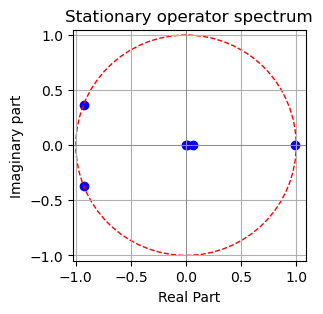

In [3]:
# --!--------------------------------------------------------------------------
# --! visualize stationary operator eigenvalues

with torch.no_grad():
    utils_plot.plot_eigs(model)

The modal amplitude plots below demonstrate that the real eigenvalues do not play much role when the model responds to input sinusoidal data---the majority of the work is carried out by one complex pair. The other complex pair idles.

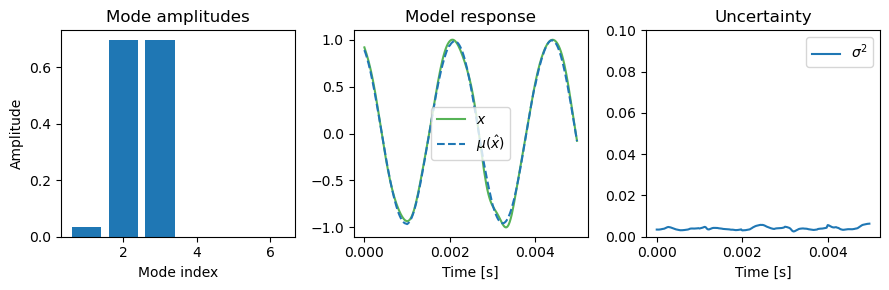

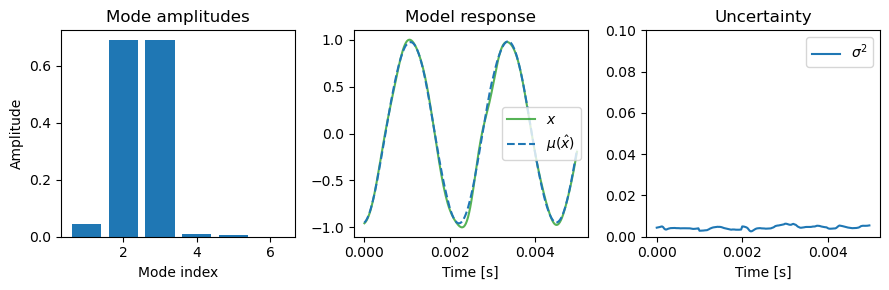

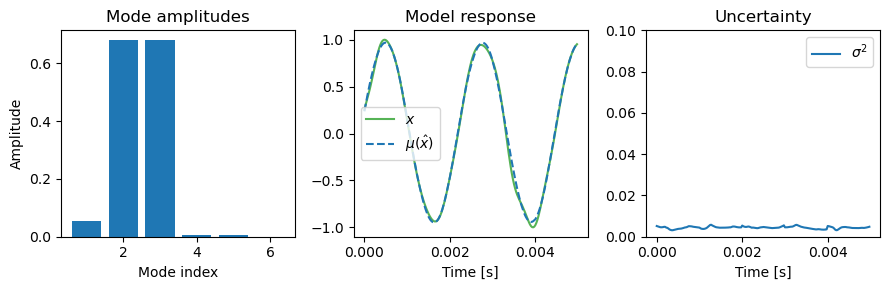

In [4]:
# --!--------------------------------------------------------------------------
# --! analyze the amplitude of global operator eigenvalues

datadir             = 'data/train_meas_g'
timeseries_nsample  = 200

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

### Model evaluation

First, the stationary operator, trained solely on stationary cavity detuning data, fails to capture the transitional behavior present in the real-world signal, such as rising or falling oscillation envelopes.

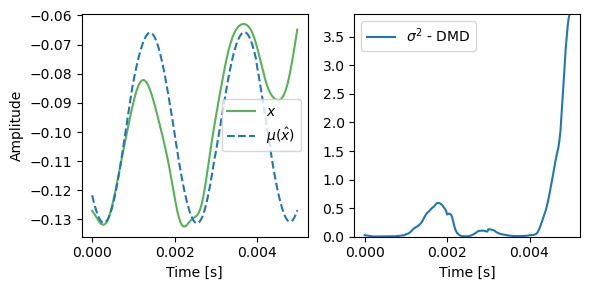

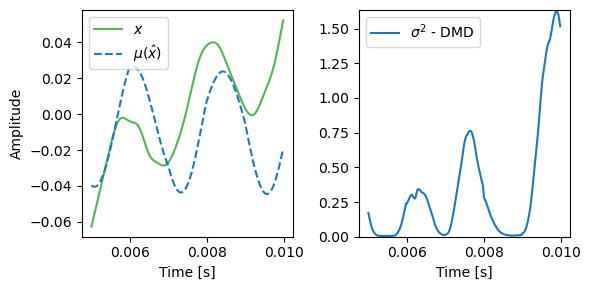

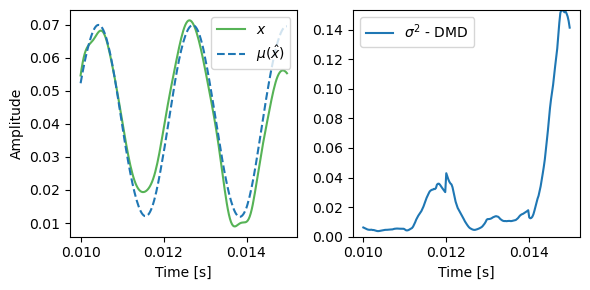

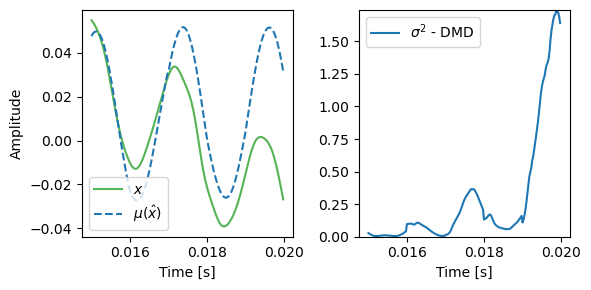

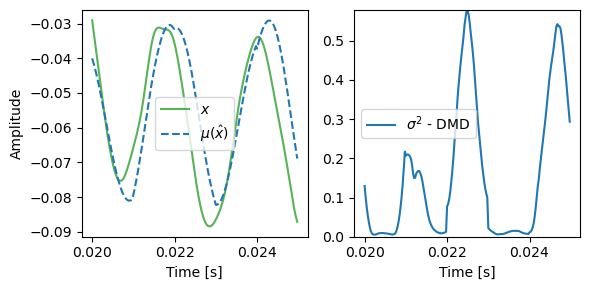

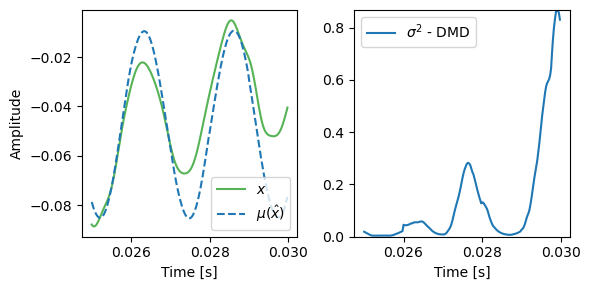

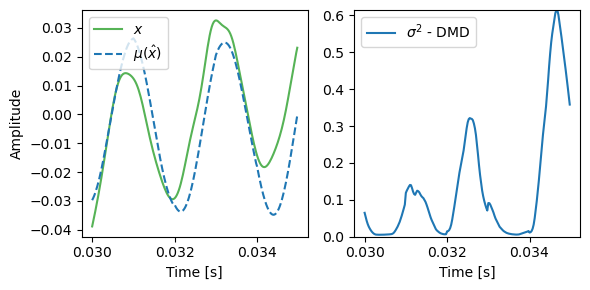

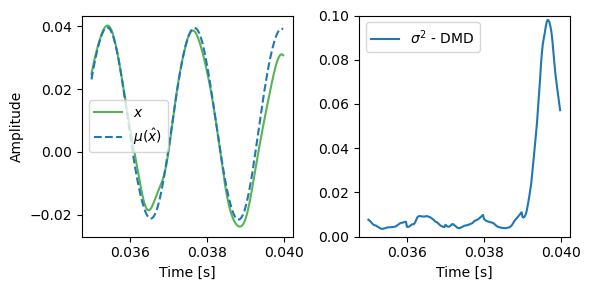

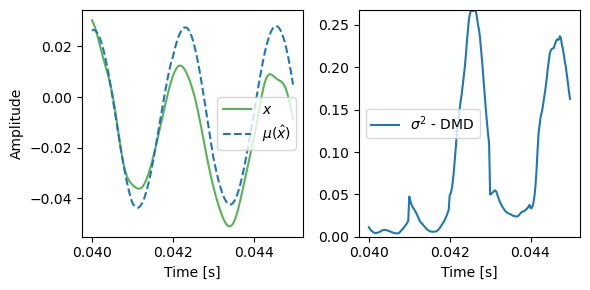

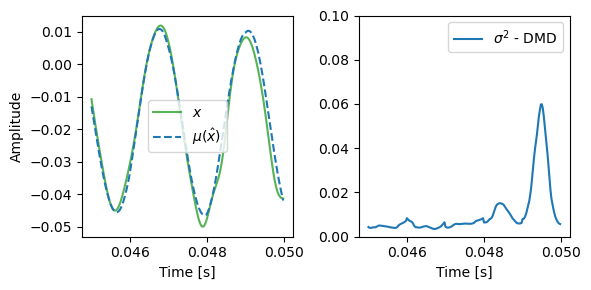

In [5]:
# --!--------------------------------------------------------------------------
# --! evaluate a global model

datadir            = 'data/eval_meas'
timeseries_nsample = 200

with torch.no_grad():
    utils_plot.plot_stationary(model, datadir, timeseries_nsample, datasaved=False)

Next, we evaluate the dynamic operator on the same data. Obviously, the operator, backed by a Transformer, can capture the transient behavior better, but still not sufficient, e.g. the last two time series.

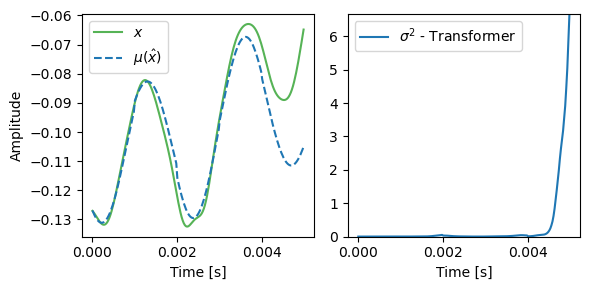

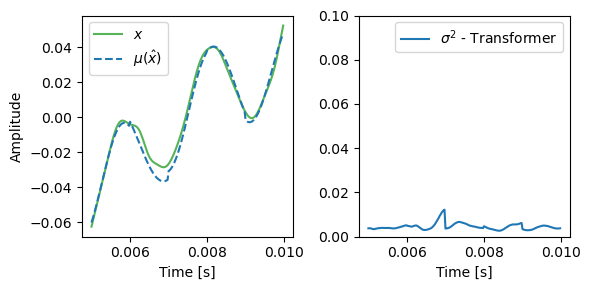

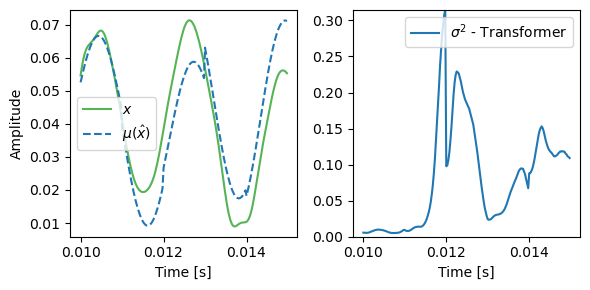

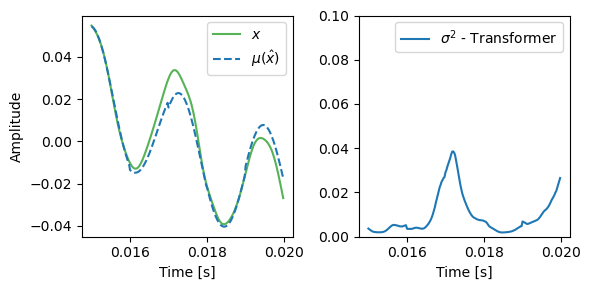

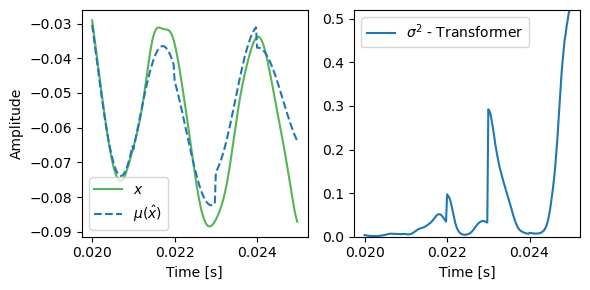

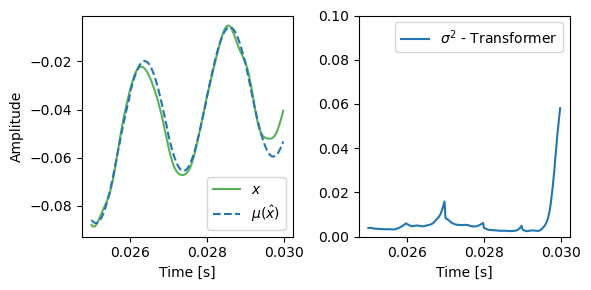

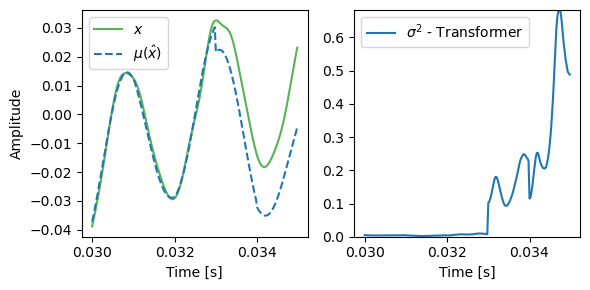

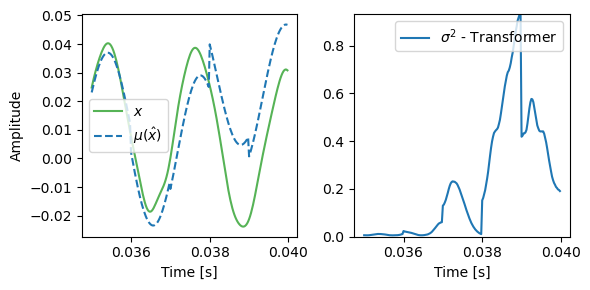

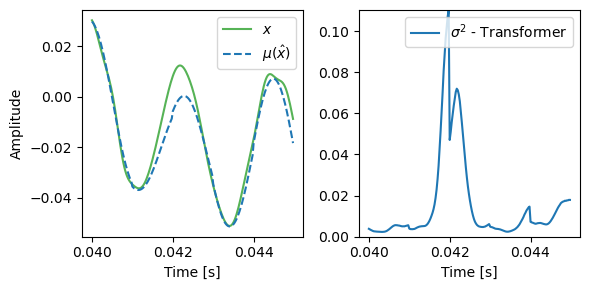

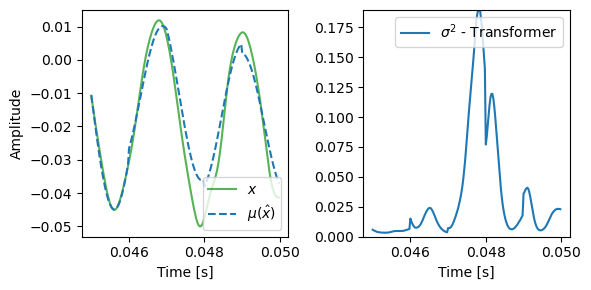

In [6]:
# --!--------------------------------------------------------------------------
# --! evaluate a dynamic model

with torch.no_grad():
    test_datadir            = 'data/eval_meas'
    test_timeseries_nsample = 200
    utils_plot.plot_transient(model, test_datadir, test_timeseries_nsample, datasaved=False)

Finally, we evaluate our alpha blending. The blending acts on a sample-by-sample level by combining the DMD and Transformer predictions with the lowest model uncertainty. This final prediction improves the previous two results.

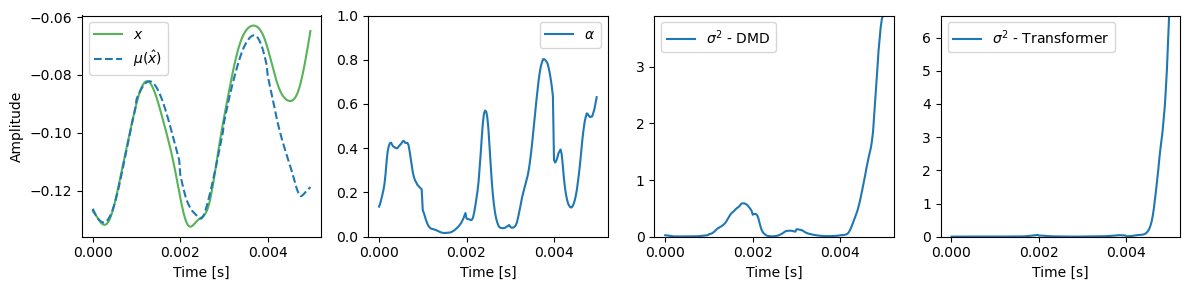

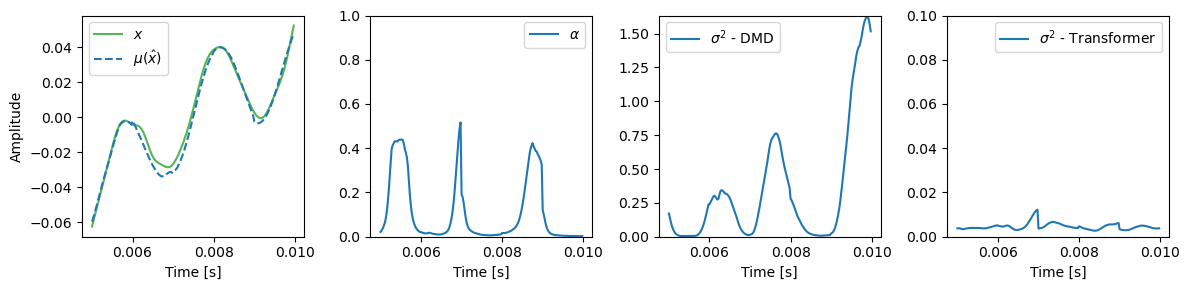

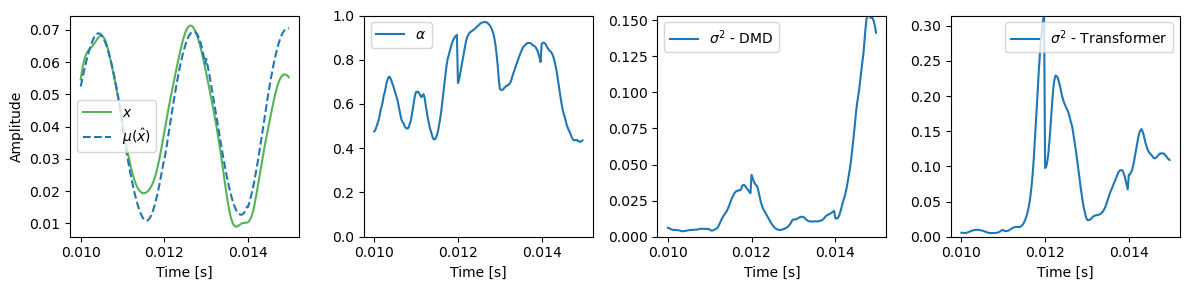

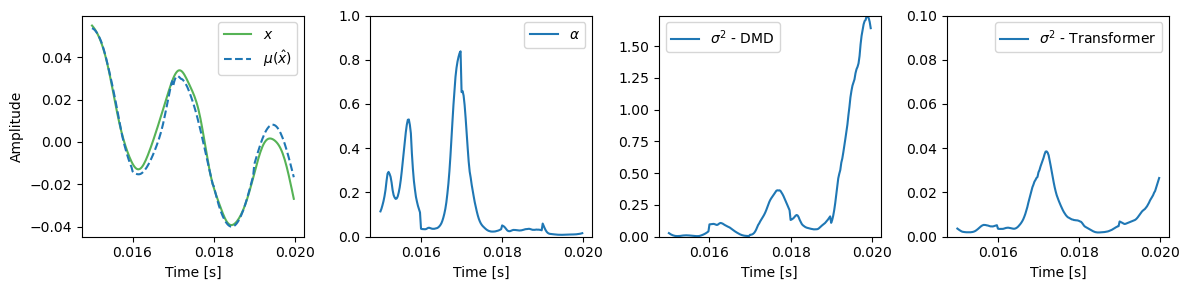

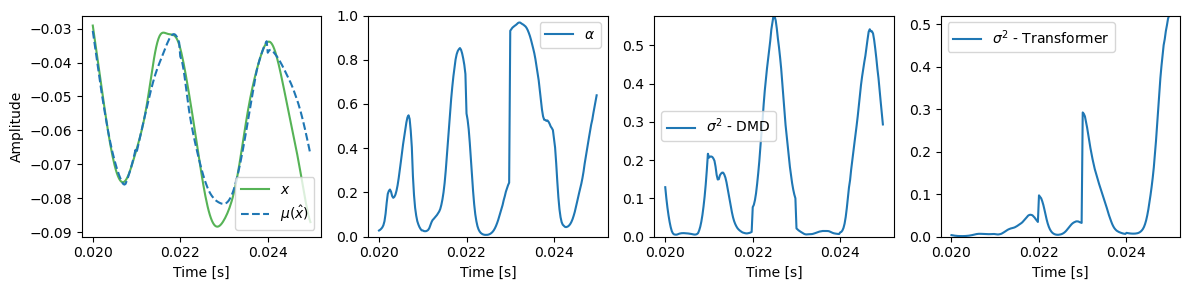

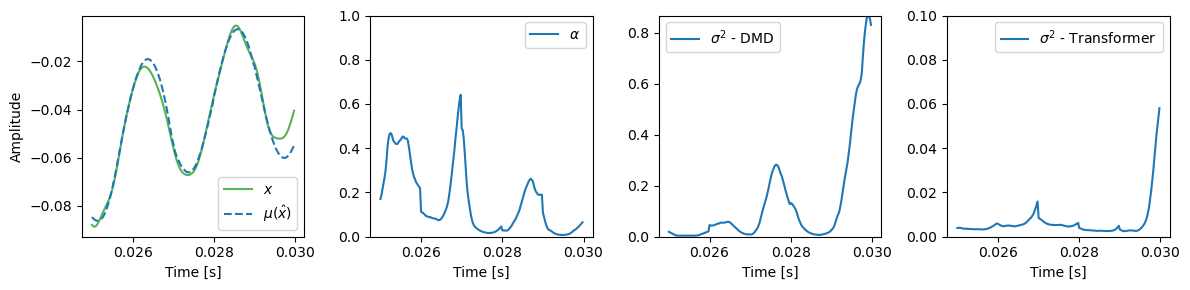

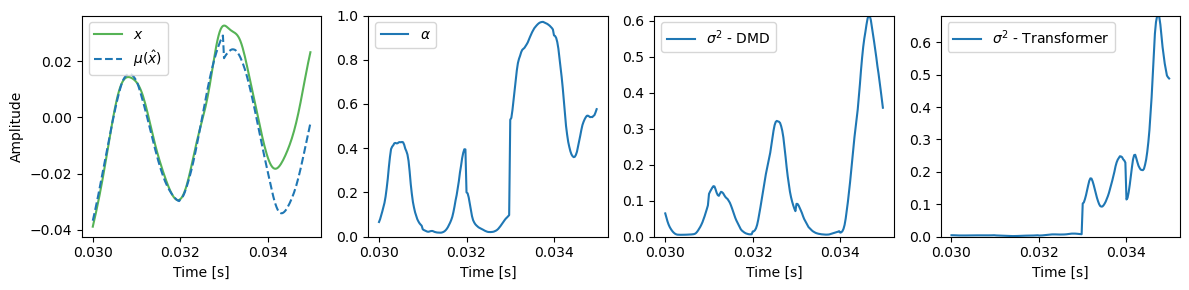

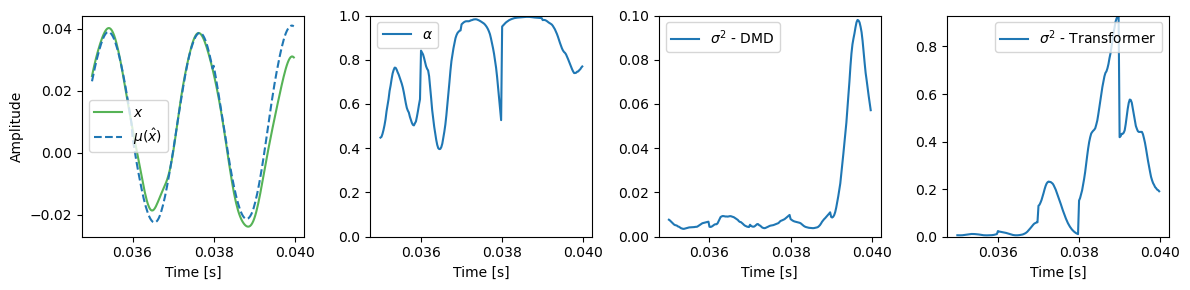

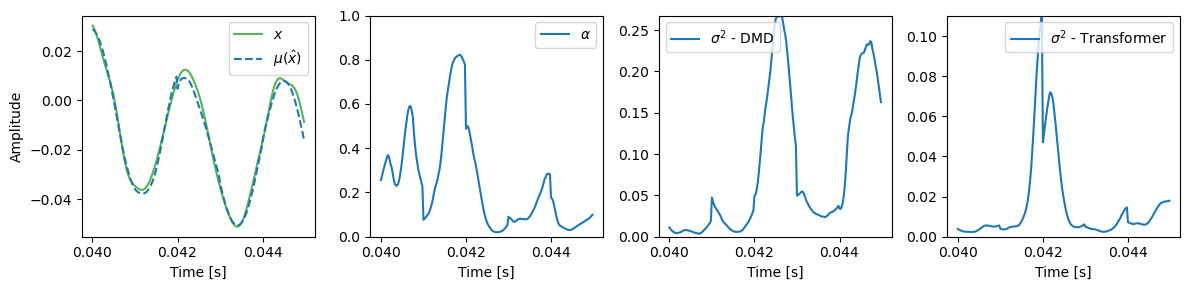

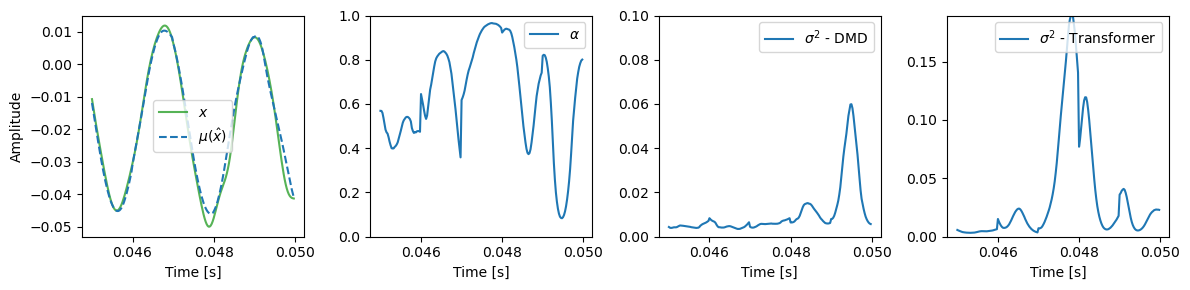

In [7]:
# --!--------------------------------------------------------------------------
# --! evaluate alpha blending

with torch.no_grad():
    test_datadir            = 'data/eval_meas'
    test_timeseries_nsample = 200
    utils_plot.plot_blend(model, test_datadir, test_timeseries_nsample, datasaved=False)